# LDA
* 선형 판별 분석법
* PCA와 유사점
  * 입력 데이터 세트를 저차원 공간에 투영해 차원을 축소
* PCA와 차이점
  * 지도 학습의 분류에서 사용하기 쉽도록 개별 클래스를 분별하는 기준을 최대한 유지하며 차원 축소함
  * PCA는 입력 데이터의 변동성 가장 큰 축 찾음 <-> LDA는 입력 데이터의 결정값 클래스를 최대한 분리하는 축을 찾음
  * 공분산 행렬이 아닌, 클래스간&내부 분산 행렬 생성하고 이 행렬에 기반해 고유벡터 구한 뒤 입력 데이터를 투영함
* 클래스 간 분산(between-class-scatter)은 최대한 크게, 클래스 내부 분산(within-class scatter)은 최대한 작게 가져가는 방식
* LDA 순서
  1. 클래스 내부와 클래스 분산 행렬 구함 : 입력 데이터의 결정값 클래스 별로 개별 피처의 평균 벡터(mean vector) 기반으로
  2. 클래스 내부 분산 행렬을 SW, 클래스 간 분산 행렬을 SB일 때, 두 행렬을 고유 벡터로 분해
  3. 고유값이 가장 큰 순으로 K개(LDA 변한 차수만큼) 추출
  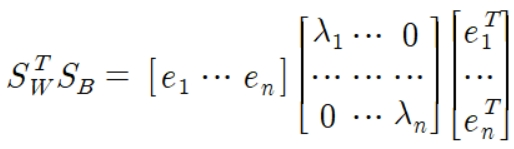
  4. 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터 변환

# 붓꽃 데이터세트에 LDA 적용하기

In [5]:
### 라이브러리 임포트

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
### 데이터 로드

iris = load_iris()
iris_scaled = StandardScaler().fit_transform(iris.data)

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris_scaled, iris.target)
iris_lda = lda.transform(iris_scaled)
print(iris_lda.shape)

(150, 2)


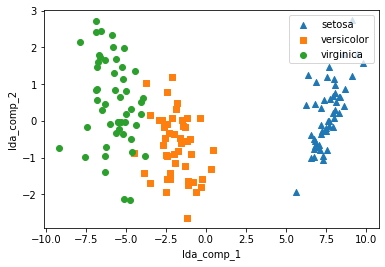

In [7]:
### 변환된 입력데이터값 시각화


col = ['lda_comp_1', 'lda_comp_2']
irisDF_lda = pd.DataFrame(iris_lda, columns=col)
irisDF_lda['target'] = iris.target

markers = ['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_lda[iris['target']==i]['lda_comp_1']
    y_axis_data = irisDF_lda[iris['target']==i]['lda_comp_2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])

plt.legend(loc='upper right')
plt.xlabel('lda_comp_1')
plt.ylabel('lda_comp_2')
plt.show()